In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import os
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
cleaned_csv_path = "cleaned_online_retail.csv"

if not os.path.exists(cleaned_csv_path):
    raise FileNotFoundError(
        "cleaned_online_retail.csv not found. "
        "Please upload the cleaned dataset."
    )

clean_df = pd.read_csv(
    cleaned_csv_path,
    parse_dates=["InvoiceDate"]
)

print("Dataset loaded successfully.")
print("Dataset shape:", clean_df.shape)

Dataset loaded successfully.
Dataset shape: (392692, 13)


In [5]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8


In [6]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
 9   Year         392692 non-null  int64         
 10  Month        392692 non-null  int64         
 11  Day          392692 non-null  int64         
 12  Hour         392692 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(7), object(3)
memory usage: 38.9+ MB


In [7]:
print("Missing values:")
print(clean_df.isnull().sum())

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
Year           0
Month          0
Day            0
Hour           0
dtype: int64


In [8]:
print("Duplicate rows:", clean_df.duplicated().sum())

Duplicate rows: 0


In [9]:
clean_df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount,Year,Month,Day,Hour
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661


In [10]:
print("Unique customers:", clean_df["CustomerID"].nunique())

Unique customers: 4338


In [11]:
reference_date = (
    clean_df["InvoiceDate"].max() +
    pd.Timedelta(days=1)
)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [12]:
rfm = clean_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (
        reference_date - x.max()
    ).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
}).reset_index()

rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

print("RFM dataset shape:", rfm.shape)

rfm.head()

RFM dataset shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [13]:
rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [15]:
print("RFM missing values:")
print(rfm.isnull().sum())

print("\nRFM duplicates:")
print(rfm.duplicated().sum())

RFM missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

RFM duplicates:
0


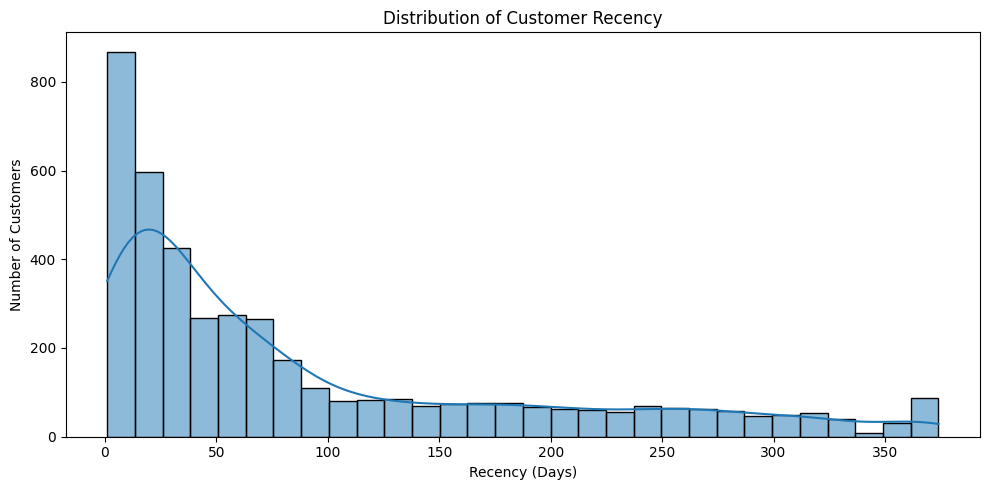

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Recency"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

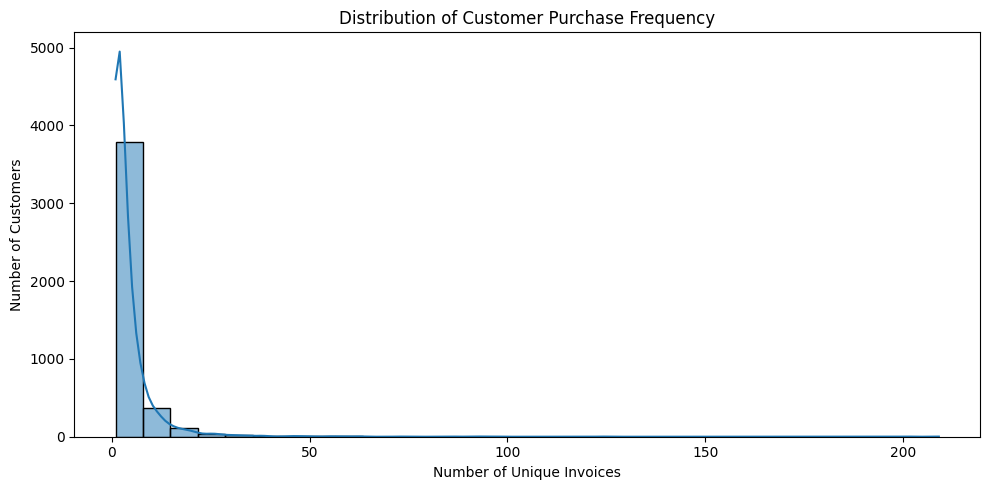

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Frequency"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Unique Invoices")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

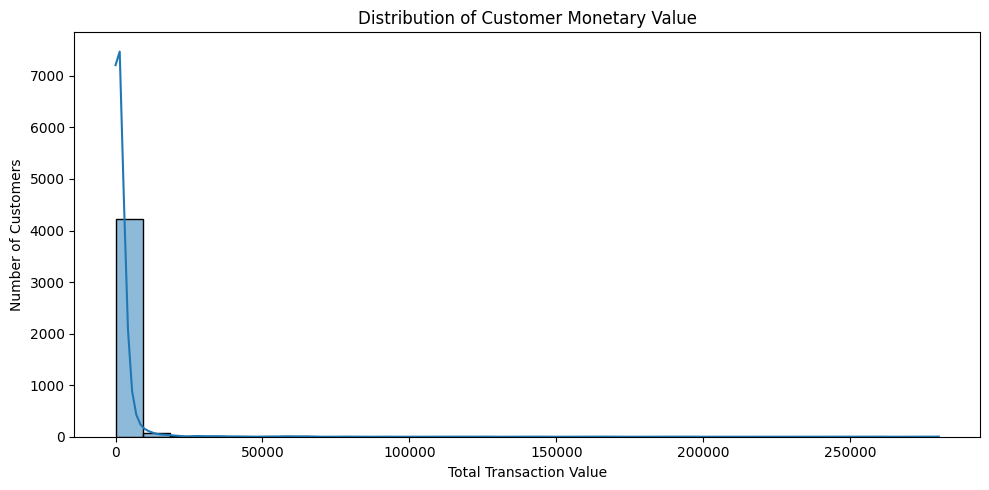

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Monetary"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Transaction Value")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

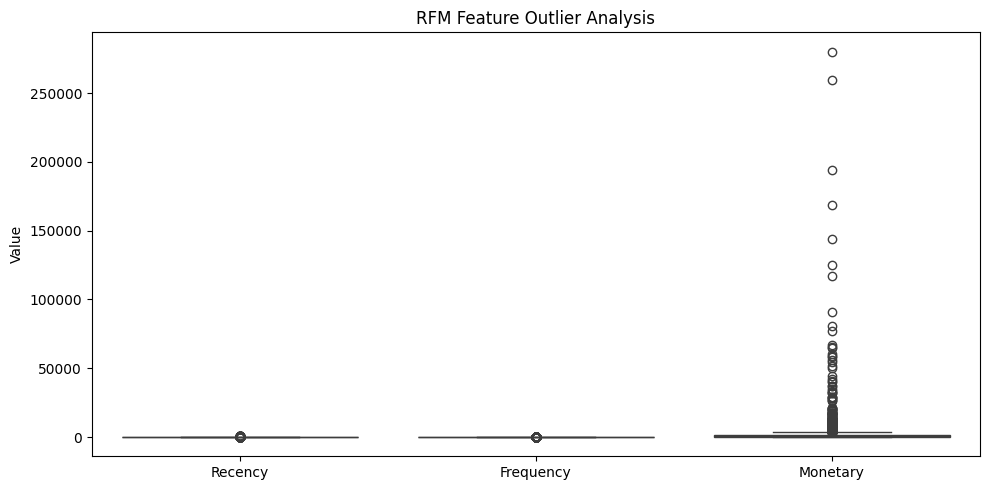

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=rfm[
        ["Recency", "Frequency", "Monetary"]
    ]
)

plt.title("RFM Feature Outlier Analysis")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [21]:
for column in ["Recency", "Frequency", "Monetary"]:

    Q1 = rfm[column].quantile(0.25)
    Q3 = rfm[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (rfm[column] < lower) |
        (rfm[column] > upper)
    ).sum()

    print(
        f"{column}: {outliers} potential outliers"
    )

Recency: 155 potential outliers
Frequency: 285 potential outliers
Monetary: 425 potential outliers


In [22]:
rfm["Recency_Log"] = np.log1p(rfm["Recency"])
rfm["Frequency_Log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_Log"] = np.log1p(rfm["Monetary"])

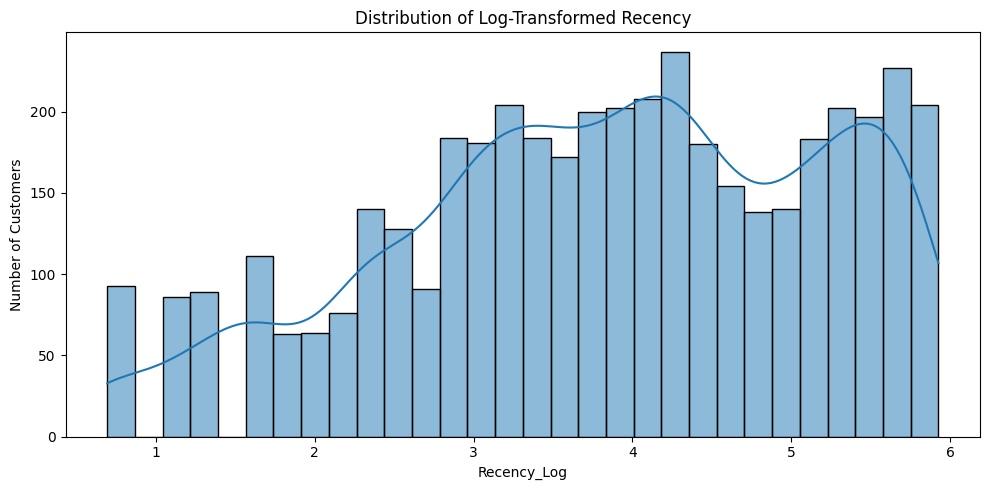

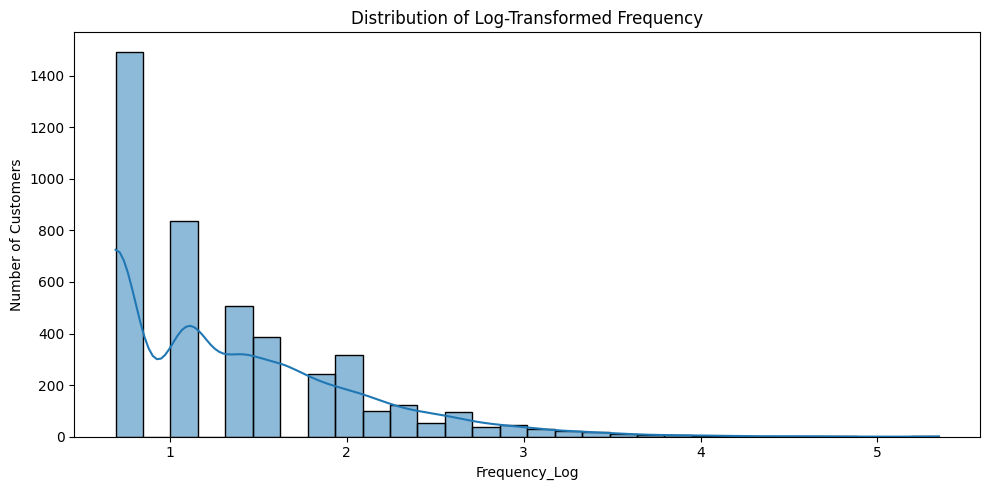

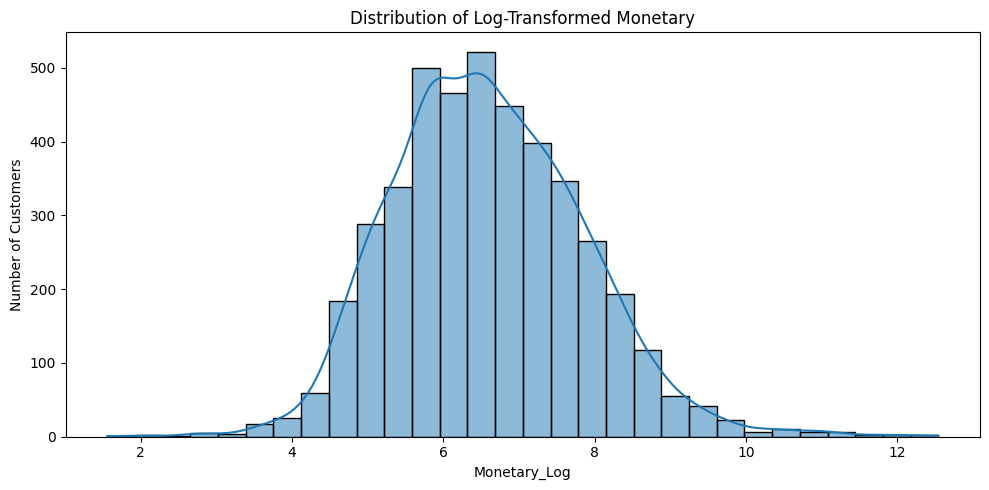

In [23]:
figures = [
    ("Recency_Log", "Distribution of Log-Transformed Recency"),
    ("Frequency_Log", "Distribution of Log-Transformed Frequency"),
    ("Monetary_Log", "Distribution of Log-Transformed Monetary")
]

for column, title in figures:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        rfm[column],
        bins=30,
        kde=True
    )

    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

In [24]:
features = rfm[
    [
        "Recency_Log",
        "Frequency_Log",
        "Monetary_Log"
    ]
]

print("Clustering features:")
print(features.head())

Clustering features:
   Recency_Log  Frequency_Log  Monetary_Log
0     5.789960       0.693147     11.253955
1     1.098612       2.079442      8.368925
2     4.330733       1.609438      7.494564
3     2.995732       0.693147      7.472245
4     5.739793       0.693147      5.815324


In [25]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=features.columns
)

rfm_scaled_df.head()

,Recency_Log,Frequency_Log,Monetary_Log
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [26]:
print(
    "Means after scaling:",
    rfm_scaled_df.mean().round(2).to_dict()
)

print(
    "Standard deviations after scaling:",
    rfm_scaled_df.std().round(2).to_dict()
)

Means after scaling: {'Recency_Log': -0.0, 'Frequency_Log': -0.0, 'Monetary_Log': -0.0}
Standard deviations after scaling: {'Recency_Log': 1.0, 'Frequency_Log': 1.0, 'Monetary_Log': 1.0}


In [27]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(k_values, inertia):
    print(f"K={k}: {value:.2f}")

Inertia values:
K=2: 6483.59
K=3: 4869.49
K=4: 3939.05
K=5: 3296.71
K=6: 2855.76
K=7: 2548.82
K=8: 2336.34
K=9: 2156.01
K=10: 2005.75


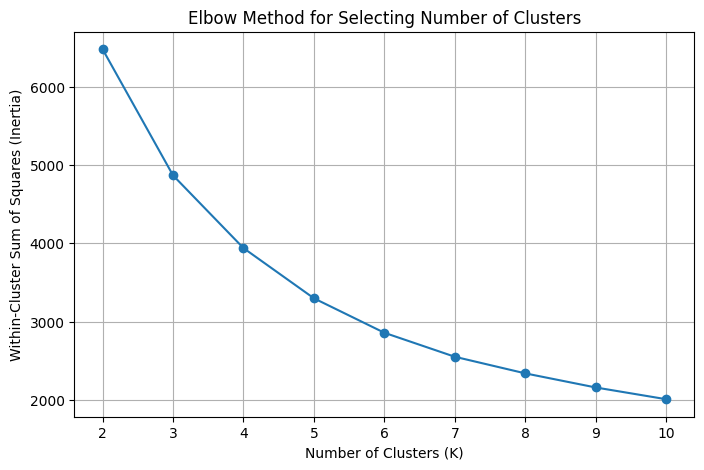

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [29]:
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}: Silhouette Score={score:.4f}")

K=2: Silhouette Score=0.4328
K=3: Silhouette Score=0.3365
K=4: Silhouette Score=0.3375
K=5: Silhouette Score=0.3162
K=6: Silhouette Score=0.3124
K=7: Silhouette Score=0.3092
K=8: Silhouette Score=0.3033
K=9: Silhouette Score=0.2811
K=10: Silhouette Score=0.2767


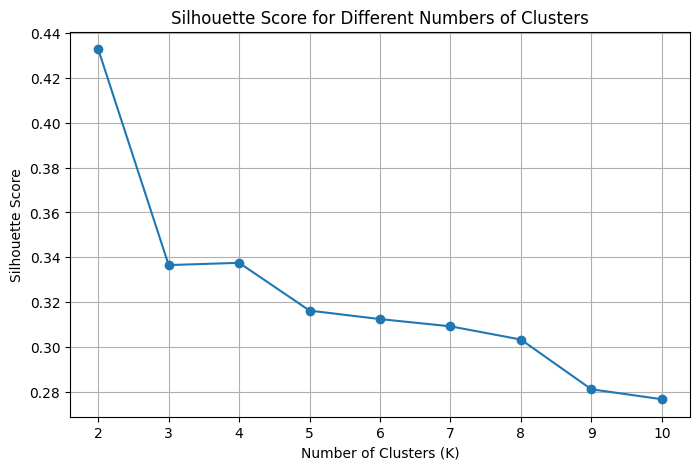

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [31]:
final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

print("Final K-Means model created successfully.")
print("Number of clusters:", final_k)

Final K-Means model created successfully.
Number of clusters: 2


In [32]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Customer count in each cluster:")
print(cluster_counts)

print("\nCluster percentages:")
print((cluster_counts / len(rfm) * 100).round(2))

Customer count in each cluster:
Cluster
0    2672
1    1666
Name: count, dtype: int64

Cluster percentages:
Cluster
0    61.6
1    38.4
Name: count, dtype: float64


In [33]:
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

print("Cluster RFM Profile:")
print(cluster_profile)

Cluster RFM Profile:
         Recency  Frequency  Monetary
Cluster                              
0         134.09       1.67    495.59
1          25.89       8.44   4539.60


In [35]:
cluster_median = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].median().round(2)

print("Cluster RFM Median:")
print(cluster_median)

Cluster RFM Median:
         Recency  Frequency  Monetary
Cluster                              
0           96.0        1.0    363.08
1           16.0        6.0   2061.07


In [36]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Customer count in each cluster:")
print(cluster_counts)

print("\nCluster percentages:")
cluster_percentages = (cluster_counts / len(rfm) * 100).round(2)
print(cluster_percentages)

Customer count in each cluster:
Cluster
0    2672
1    1666
Name: count, dtype: int64

Cluster percentages:
Cluster
0    61.6
1    38.4
Name: count, dtype: float64


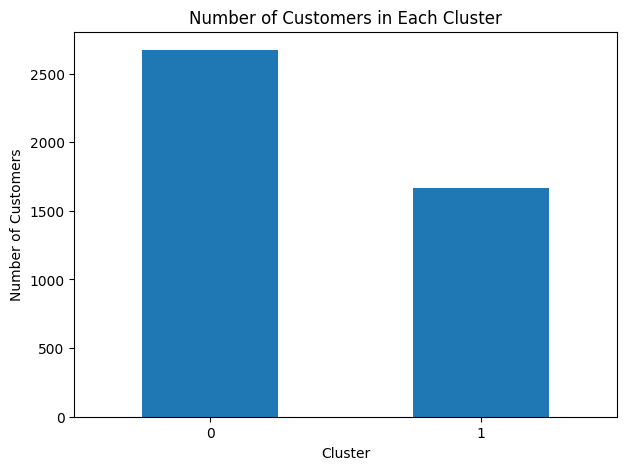

In [37]:
plt.figure(figsize=(7, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [38]:
from sklearn.decomposition import PCA

In [39]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.75078634 0.18786648]

Total variance explained:
0.9386528181989533


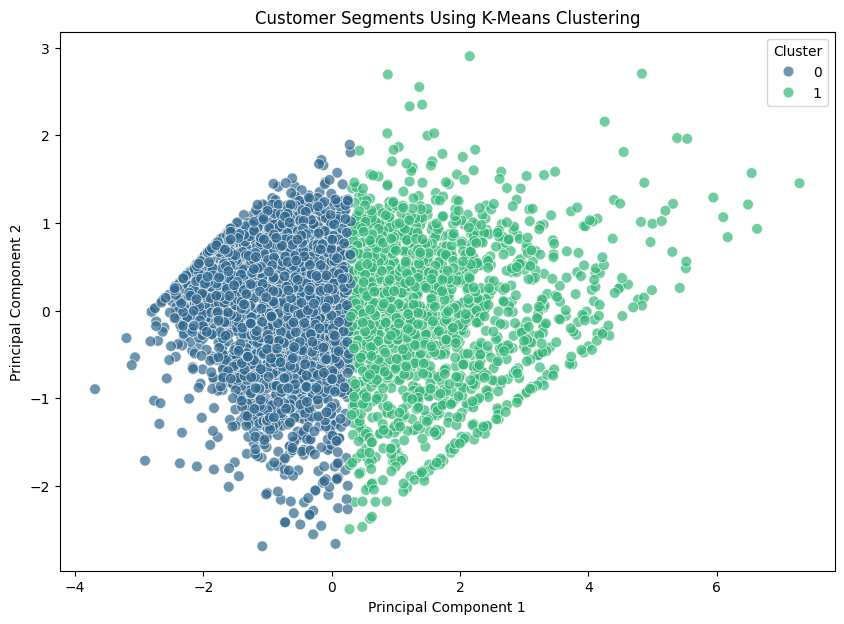

In [41]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    s=60,
    alpha=0.7
)

plt.title("Customer Segments Using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [42]:
from mpl_toolkits.mplot3d import Axes3D

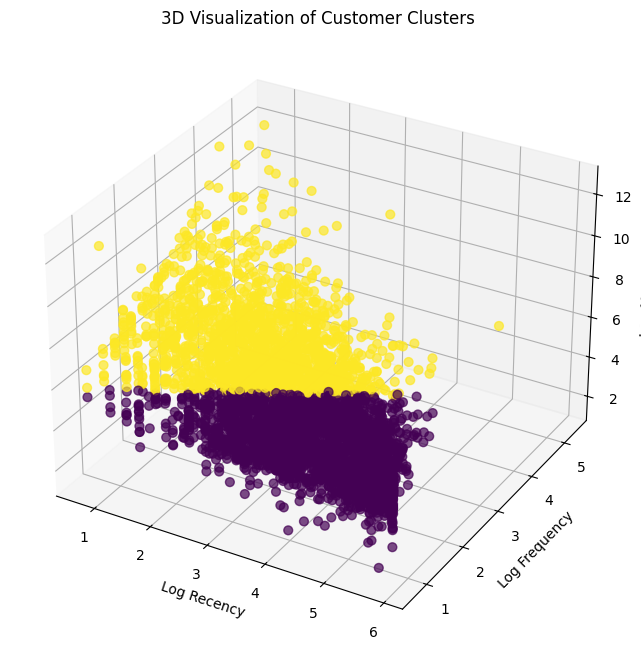

In [43]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    rfm["Recency_Log"],
    rfm["Frequency_Log"],
    rfm["Monetary_Log"],
    c=rfm["Cluster"],
    cmap="viridis",
    s=40,
    alpha=0.7
)

ax.set_title("3D Visualization of Customer Clusters")
ax.set_xlabel("Log Recency")
ax.set_ylabel("Log Frequency")
ax.set_zlabel("Log Monetary")

plt.show()

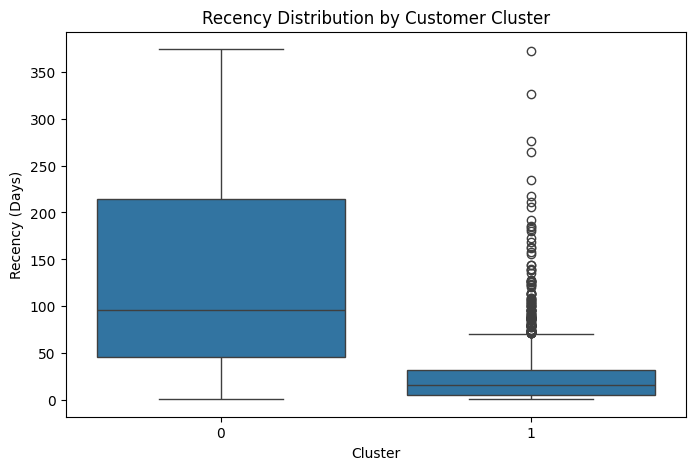

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rfm,
    x="Cluster",
    y="Recency"
)

plt.title("Recency Distribution by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Recency (Days)")

plt.show()

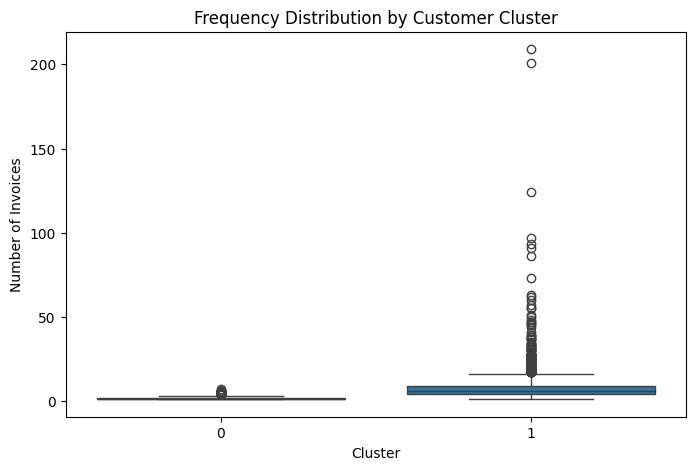

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rfm,
    x="Cluster",
    y="Frequency"
)

plt.title("Frequency Distribution by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Invoices")

plt.show()

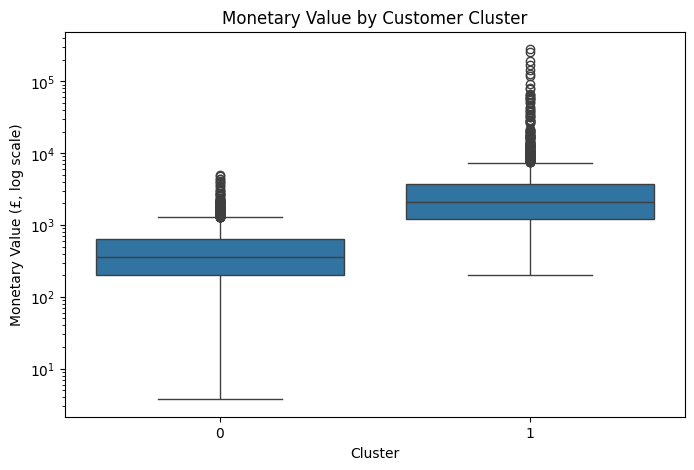

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rfm,
    x="Cluster",
    y="Monetary"
)

plt.yscale("log")

plt.title("Monetary Value by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Monetary Value (£, log scale)")

plt.show()

In [47]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Median_Recency=("Recency", "median"),
    Avg_Frequency=("Frequency", "mean"),
    Median_Frequency=("Frequency", "median"),
    Avg_Monetary=("Monetary", "mean"),
    Median_Monetary=("Monetary", "median")
).round(2)

cluster_summary["Customer_Percentage"] = (
    cluster_summary["Customers"] / len(rfm) * 100
).round(2)

print(cluster_summary)

         Customers  Avg_Recency  Median_Recency  Avg_Frequency  \
Cluster                                                          
0             2672       134.09            96.0           1.67   
1             1666        25.89            16.0           8.44   

         Median_Frequency  Avg_Monetary  Median_Monetary  Customer_Percentage  
Cluster                                                                        
0                     1.0        495.59           363.08                 61.6  
1                     6.0       4539.60          2061.07                 38.4  


In [48]:
cluster_rfm_mean = rfm.groupby("Cluster")[
    ["Recency_Log", "Frequency_Log", "Monetary_Log"]
].mean()

cluster_rfm_mean

,Recency_Log,Frequency_Log,Monetary_Log
Cluster,,,
0,4.505972,0.933742,5.875465
1,2.747758,2.006109,7.732258


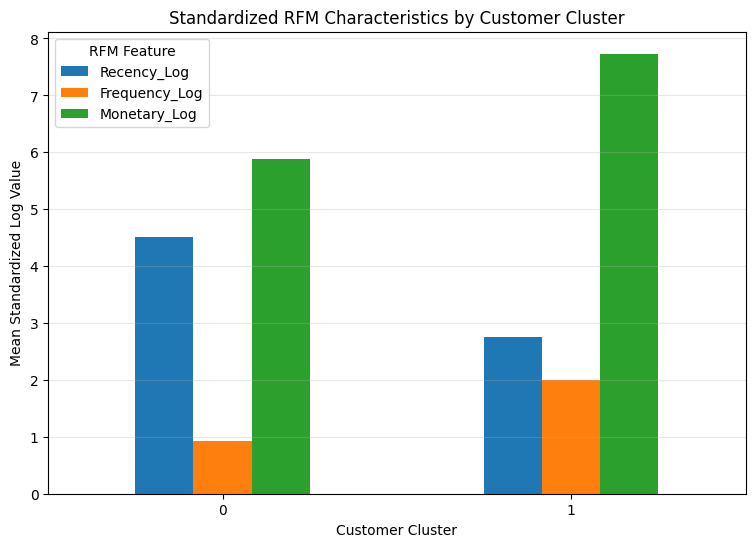

In [49]:
cluster_rfm_mean.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Standardized RFM Characteristics by Customer Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Mean Standardized Log Value")
plt.xticks(rotation=0)
plt.legend(title="RFM Feature")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [50]:
output_file = "customer_rfm_clusters.csv"

rfm.to_csv(output_file, index=False)

print(f"Customer segmentation dataset saved as: {output_file}")
print("Shape:", rfm.shape)

Customer segmentation dataset saved as: customer_rfm_clusters.csv
Shape: (4338, 10)


In [51]:
from google.colab import files

files.download("customer_rfm_clusters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print(f"Final number of clusters: {final_k}")
print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final number of clusters: 2
Final Silhouette Score: 0.4328


In [53]:
final_summary = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Median_Recency=("Recency", "median"),
    Avg_Frequency=("Frequency", "mean"),
    Median_Frequency=("Frequency", "median"),
    Avg_Monetary=("Monetary", "mean"),
    Median_Monetary=("Monetary", "median")
).round(2)

final_summary["Customer_Percentage"] = (
    final_summary["Customers"] / len(rfm) * 100
).round(2)

print("FINAL CUSTOMER SEGMENTATION SUMMARY")
print(final_summary)

FINAL CUSTOMER SEGMENTATION SUMMARY
         Customers  Avg_Recency  Median_Recency  Avg_Frequency  \
Cluster                                                          
0             2672       134.09            96.0           1.67   
1             1666        25.89            16.0           8.44   

         Median_Frequency  Avg_Monetary  Median_Monetary  Customer_Percentage  
Cluster                                                                        
0                     1.0        495.59           363.08                 61.6  
1                     6.0       4539.60          2061.07                 38.4  


In [54]:
print("FINAL MODEL PARAMETERS")
print("----------------------")
print("Algorithm: K-Means")
print("Number of clusters (K):", final_k)
print("Random state:", 42)
print("n_init:", 10)
print("Features used:")
print("- Recency_Log")
print("- Frequency_Log")
print("- Monetary_Log")
print("Scaling method: StandardScaler")
print("Final Silhouette Score:", round(final_silhouette, 4))

FINAL MODEL PARAMETERS
----------------------
Algorithm: K-Means
Number of clusters (K): 2
Random state: 42
n_init: 10
Features used:
- Recency_Log
- Frequency_Log
- Monetary_Log
Scaling method: StandardScaler
Final Silhouette Score: 0.4328


In [55]:
print("PCA VISUALIZATION RESULTS")
print("-------------------------")
print("PC1 variance explained:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 variance explained:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PCA VISUALIZATION RESULTS
-------------------------
PC1 variance explained: 75.08 %
PC2 variance explained: 18.79 %
Total variance explained: 93.87 %


In [56]:
final_results = {
    "Dataset Customers": len(rfm),
    "Number of Clusters": final_k,
    "Silhouette Score": round(final_silhouette, 4),
    "Cluster 0 Customers": int(cluster_counts[0]),
    "Cluster 1 Customers": int(cluster_counts[1]),
    "Cluster 0 Percentage": float(cluster_percentages[0]),
    "Cluster 1 Percentage": float(cluster_percentages[1]),
    "PCA Variance Explained": round(
        pca.explained_variance_ratio_.sum() * 100, 2
    )
}

print(final_results)

{'Dataset Customers': 4338, 'Number of Clusters': 2, 'Silhouette Score': np.float64(0.4328), 'Cluster 0 Customers': 2672, 'Cluster 1 Customers': 1666, 'Cluster 0 Percentage': 61.6, 'Cluster 1 Percentage': 38.4, 'PCA Variance Explained': np.float64(93.87)}
